In [ ]:
import zipfile
with zipfile.ZipFile("mri2.zip", 'r') as zip_ref:
   zip_ref.extractall()

In [ ]:
import cv2
import os
import numpy as np
import pandas as pd
from math import exp, sqrt
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
import matplotlib.image as mpimg
from sklearn.utils import shuffle
import keras
import tensorflow as tf
import tensorflow.keras.backend as K
from keras import Input
from keras.models import Model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import  BatchNormalization, Concatenate, Add, DepthwiseConv2D, GlobalAveragePooling2D, SeparableConv2D
from tensorflow.keras.optimizers import SGD,RMSprop,Adam,Adagrad
from keras.layers import Conv2D, MaxPooling2D

2024-09-10 04:14:19.656042: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-10 04:14:19.656103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-10 04:14:19.657570: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-10 04:14:19.665934: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
data_path = 'MRI2'
data_dir_list = os.listdir(data_path)
img_data_list = []
labels = []

for dataset in data_dir_list:
    img_list = os.listdir(os.path.join(data_path, dataset))
    print('Loaded the images of dataset-{}\n'.format(dataset))
    for img in img_list:
        if img.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_img = cv2.imread(os.path.join(data_path, dataset, img))
            if input_img is not None:
                img = cv2.resize(input_img, (224, 224))
                labels.append(dataset)
                img_data_list.append(img)

label = np.array(labels)
img_data = np.array(img_data_list)
img_data = img_data.astype('float32')
img_data = img_data / 255.0
print(img_data.shape)

Loaded the images of dataset-CN

Loaded the images of dataset-SMC

Loaded the images of dataset-LMCI

Loaded the images of dataset-MCI

Loaded the images of dataset-EMCI

Loaded the images of dataset-AD

(9752, 224, 224, 3)


In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

class_names = ['CN', 'SMC', 'LMCI', 'MCI', 'EMCI', 'AD']
class_mapping = {name: idx for idx, name in enumerate(class_names)}
integer_labels = [class_mapping[label] for label in labels]
num_classes = len(class_names)
Y = to_categorical(integer_labels, num_classes)
x, y = shuffle(img_data, Y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7801, 224, 224, 3)
X_test shape: (1951, 224, 224, 3)
y_train shape: (7801, 6)
y_test shape: (1951, 6)


In [ ]:
X_train = X_train.reshape(-1, 224, 224, 3)
X_test = X_test.reshape(-1, 224, 224, 3)

In [ ]:
import keras
from keras.models import Model
from tensorflow.keras import regularizers
from keras.layers import Input, Conv2D, Add, Multiply, Concatenate, AveragePooling2D, Flatten, DepthwiseConv2D, BatchNormalization
from keras.layers import SeparableConv2D, MaxPooling2D, Dense, GlobalAveragePooling2D, Activation
from tensorflow.keras.applications import ResNet50, VGG16, MobileNet

base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:12]:
    layer.trainable = False
x = base_model.output
x1 = Conv2D(64, (3, 3),  dilation_rate = 1, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x1 = BatchNormalization()(x1)
x2 = Conv2D(64, (3, 3),  dilation_rate = 3, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x2 = BatchNormalization()(x2)
x3 = Conv2D(64, (3, 3),  dilation_rate = 5, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x3 = BatchNormalization()(x3)

A1 = Add()([x1, x2])
M1 = Multiply()([x2, x3])

x4 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(A1)
x4 = BatchNormalization()(x4)
g1 = GlobalAveragePooling2D()(x4)
d1 = Dense(1, activation = 'sigmoid')(g1)
M3 = Multiply()([d1, x1])

x5 = Activation('softmax')(M1)
M2 = Multiply()([x3, x5])

C1 = Concatenate()([M2, M3])
x5 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(C1)
C2 = Concatenate()([x5, x])

x = GlobalAveragePooling2D()(C2)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output = Dense(6, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='RMSprop', loss='categorical_crossentropy', metrics=['acc'])
#model.summary()

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
                              patience=30,
                              min_delta=0.001,
                              monitor="val_acc",
                              restore_best_weights=True
                              )
# Define the model checkpoint callback to save the best weights
#checkpoint = ModelCheckpoint('/workspace/notebooks/Mri - Alzimers/Data /Check/'+'-{epoch:02d}.h5', monitor='val_acc', save_best_only=True)


history = model.fit( X_train, y_train, batch_size = 32, epochs = 200,
                    validation_data = (X_test , y_test), callbacks=[early_stopping], verbose =1)

Epoch 1/200


2024-09-10 04:16:47.791863: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90100
2024-09-10 04:16:49.399263: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f85f57e0690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-09-10 04:16:49.399308: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB MIG 3g.20gb, Compute Capability 8.0
2024-09-10 04:16:49.405488: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1725941809.499801    1573 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


244/244 [==============================] - 34s 77ms/step - loss: 17.0175 - acc: 0.4665 - val_loss: 11.2216 - val_acc: 0.4546
Epoch 2/200
244/244 [==============================] - 12s 51ms/step - loss: 10.4345 - acc: 0.5934 - val_loss: 10.4734 - val_acc: 0.5500
Epoch 3/200
244/244 [==============================] - 13s 52ms/step - loss: 10.1504 - acc: 0.7250 - val_loss: 12.5150 - val_acc: 0.3885
Epoch 4/200
244/244 [==============================] - 12s 47ms/step - loss: 9.9334 - acc: 0.8095 - val_loss: 10.4164 - val_acc: 0.6648
Epoch 5/200
244/244 [==============================] - 12s 48ms/step - loss: 9.7890 - acc: 0.8646 - val_loss: 10.9949 - val_acc: 0.6330
Epoch 6/200
244/244 [==============================] - 11s 45ms/step - loss: 9.7130 - acc: 0.8924 - val_loss: 10.4742 - val_acc: 0.6571
Epoch 7/200
244/244 [==============================] - 12s 47ms/step - loss: 9.6665 - acc: 0.9126 - val_loss: 10.2799 - val_acc: 0.7668
Epoch 8/200
244/244 [==============================] - 10

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predicting the Test set results
pred = model.predict(X_test)
print("Y_pred:", pred)
print("*****************")
y_pred = np.argmax(pred, axis = 1)
y_true = np.argmax(y_test, axis = 1)

61/61 [==============================] - 1s 15ms/step - loss: 10.3357 - acc: 0.8365
Test Loss: 10.335686683654785
Test Accuracy: 0.8364940881729126
61/61 [==============================] - 3s 14ms/step
Y_pred: [[1.2514050e-07 6.0142277e-08 1.6055807e-08 9.5852934e-09 9.9999976e-01
  7.7360980e-09]
 [8.0206003e-03 3.2706431e-04 8.2548815e-01 4.0299678e-04 1.6419031e-01
  1.5709151e-03]
 [1.4062254e-13 1.0000000e+00 8.5210682e-19 1.8308785e-18 1.7643701e-17
  3.3565184e-28]
 ...
 [9.7681957e-01 8.9033268e-04 5.7445618e-04 4.2234939e-03 1.6755706e-02
  7.3644955e-04]
 [1.5160125e-09 2.2087713e-19 1.4234156e-12 5.9644943e-14 8.5443024e-13
  1.0000000e+00]
 [1.6260633e-01 7.5467173e-03 3.1132883e-01 2.2297329e-03 4.8577678e-01
  3.0511623e-02]]
*****************


Text(0.5, 15.049999999999999, 'Predicted label')

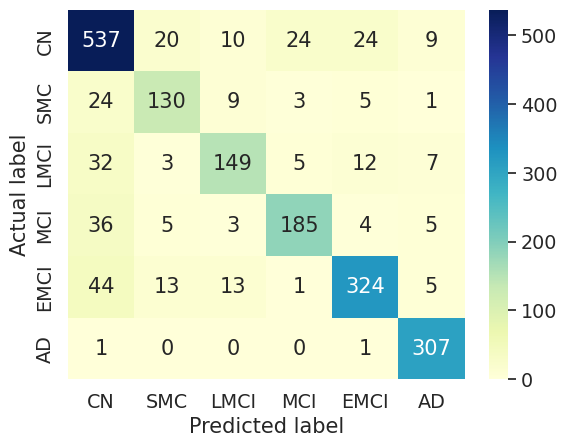

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
target_names = ["CN",

"SMC",

"LMCI",

"MCI",

"EMCI",

"AD"]
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(font_scale=1.25)
p = sns.heatmap(pd.DataFrame(cm), annot=True,xticklabels=target_names, yticklabels=target_names, cmap="YlGnBu" ,fmt='g')
plt.title('RMSprop', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
import keras
from keras.models import Model
from tensorflow.keras import regularizers
from keras.layers import Input, Conv2D, Add, Multiply, Concatenate, AveragePooling2D, Flatten, DepthwiseConv2D, BatchNormalization
from keras.layers import SeparableConv2D, MaxPooling2D, Dense, GlobalAveragePooling2D, Activation
from tensorflow.keras.applications import ResNet50, VGG16, MobileNet

base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:12]:
    layer.trainable = False
x = base_model.output
x1 = Conv2D(64, (3, 3),  dilation_rate = 1, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x1 = BatchNormalization()(x1)
x2 = Conv2D(64, (3, 3),  dilation_rate = 3, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x2 = BatchNormalization()(x2)
x3 = Conv2D(64, (3, 3),  dilation_rate = 5, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x3 = BatchNormalization()(x3)

A1 = Add()([x1, x2])
M1 = Multiply()([x2, x3])

x4 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(A1)
x4 = BatchNormalization()(x4)
g1 = GlobalAveragePooling2D()(x4)
d1 = Dense(1, activation = 'sigmoid')(g1)
M3 = Multiply()([d1, x1])

x5 = Activation('softmax')(M1)
M2 = Multiply()([x3, x5])

C1 = Concatenate()([M2, M3])
x5 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(C1)
C2 = Concatenate()([x5, x])

x = GlobalAveragePooling2D()(C2)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output = Dense(6, activation='softmax')(x)
model1 = Model(inputs=base_model.input, outputs=output)
model1.compile(optimizer='Adagrad', loss='categorical_crossentropy', metrics=['acc'])
#model.summary()

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
                              patience=30,
                              min_delta=0.001,
                              monitor="val_acc",
                              restore_best_weights=True
                              )
# Define the model checkpoint callback to save the best weights
#checkpoint = ModelCheckpoint('/workspace/notebooks/Mri - Alzimers/Data /Check/'+'-{epoch:02d}.h5', monitor='val_acc', save_best_only=True)


history = model1.fit( X_train, y_train, batch_size = 32, epochs = 200,
                    validation_data = (X_test , y_test), callbacks=[early_stopping], verbose =1)

Epoch 1/200
244/244 [==============================] - 25s 51ms/step - loss: 194.7501 - acc: 0.3943 - val_loss: 137.6062 - val_acc: 0.4700
Epoch 2/200
244/244 [==============================] - 10s 42ms/step - loss: 97.0230 - acc: 0.5012 - val_loss: 63.0202 - val_acc: 0.5110
Epoch 3/200
244/244 [==============================] - 10s 43ms/step - loss: 41.1624 - acc: 0.5704 - val_loss: 24.4426 - val_acc: 0.5792
Epoch 4/200
244/244 [==============================] - 10s 43ms/step - loss: 16.9505 - acc: 0.6304 - val_loss: 13.2063 - val_acc: 0.6084
Epoch 5/200
244/244 [==============================] - 10s 43ms/step - loss: 11.3235 - acc: 0.6944 - val_loss: 9.8617 - val_acc: 0.6330
Epoch 6/200
244/244 [==============================] - 11s 43ms/step - loss: 8.2443 - acc: 0.7668 - val_loss: 7.1987 - val_acc: 0.6453
Epoch 7/200
244/244 [==============================] - 10s 42ms/step - loss: 5.8240 - acc: 0.8239 - val_loss: 5.0948 - val_acc: 0.6827
Epoch 8/200
244/244 [=======================

In [ ]:
loss, accuracy = model1.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predicting the Test set results
pred = model1.predict(X_test)
print("Y_pred:", pred)
print("*****************")
y_pred1 = np.argmax(pred, axis = 1)
y_true1 = np.argmax(y_test, axis = 1)

61/61 [==============================] - 1s 15ms/step - loss: 0.6947 - acc: 0.8216
Test Loss: 0.6946994662284851
Test Accuracy: 0.8216299414634705
61/61 [==============================] - 3s 14ms/step
Y_pred: [[9.95199152e-05 1.89120474e-03 1.35256632e-04 4.54063138e-06
  9.97827947e-01 4.15007926e-05]
 [2.03947444e-03 3.52322892e-03 1.49476193e-02 1.92792777e-06
  9.77029264e-01 2.45850882e-03]
 [9.02170062e-01 8.07539448e-02 4.68849996e-03 1.22743575e-02
  1.11381240e-04 1.78008077e-06]
 ...
 [7.49570489e-01 2.90649536e-04 2.33445302e-01 8.27213225e-05
  1.65996626e-02 1.12325215e-05]
 [2.02526309e-04 7.68537120e-06 2.78116728e-04 3.63402432e-05
  6.55938420e-05 9.99409676e-01]
 [1.71556300e-03 3.16831902e-05 3.32680494e-01 3.05939784e-06
  6.65554225e-01 1.49767329e-05]]
*****************


Text(0.5, 15.049999999999999, 'Predicted label')

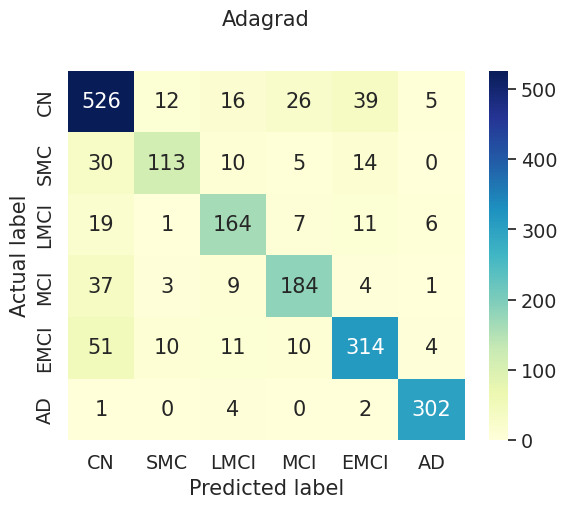

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true1, y_pred1)
target_names = ["CN",

"SMC",

"LMCI",

"MCI",

"EMCI",

"AD"]
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(font_scale=1.25)
p = sns.heatmap(pd.DataFrame(cm), annot=True,xticklabels=target_names, yticklabels=target_names, cmap="YlGnBu" ,fmt='g')
plt.title('Adagrad', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [ ]:
import keras
from keras.models import Model
from tensorflow.keras import regularizers
from keras.layers import Input, Conv2D, Add, Multiply, Concatenate, AveragePooling2D, Flatten, DepthwiseConv2D, BatchNormalization
from keras.layers import SeparableConv2D, MaxPooling2D, Dense, GlobalAveragePooling2D, Activation
from tensorflow.keras.applications import ResNet50, VGG16, MobileNet

base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:12]:
    layer.trainable = False
x = base_model.output
x1 = Conv2D(64, (3, 3),  dilation_rate = 1, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x1 = BatchNormalization()(x1)
x2 = Conv2D(64, (3, 3),  dilation_rate = 3, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x2 = BatchNormalization()(x2)
x3 = Conv2D(64, (3, 3),  dilation_rate = 5, padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(x)
x3 = BatchNormalization()(x3)

A1 = Add()([x1, x2])
M1 = Multiply()([x2, x3])

x4 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(A1)
x4 = BatchNormalization()(x4)
g1 = GlobalAveragePooling2D()(x4)
d1 = Dense(1, activation = 'sigmoid')(g1)
M3 = Multiply()([d1, x1])

x5 = Activation('softmax')(M1)
M2 = Multiply()([x3, x5])

C1 = Concatenate()([M2, M3])
x5 = Conv2D(64, (3, 3), padding = 'same', kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu')(C1)
C2 = Concatenate()([x5, x])

x = GlobalAveragePooling2D()(C2)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output = Dense(6, activation='softmax')(x)
model2 = Model(inputs=base_model.input, outputs=output)
model2.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['acc'])
#model.summary()

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
                              patience=30,
                              min_delta=0.001,
                              monitor="val_acc",
                              restore_best_weights=True
                              )
# Define the model checkpoint callback to save the best weights
#checkpoint = ModelCheckpoint('/workspace/notebooks/Mri - Alzimers/Data /Check/'+'-{epoch:02d}.h5', monitor='val_acc', save_best_only=True)


history = model2.fit( X_train, y_train, batch_size = 16, epochs = 200,
                    validation_data = (X_test , y_test), callbacks=[early_stopping], verbose =1)

Epoch 1/200
488/488 [==============================] - ETA: 0s - loss: 53.5478 - acc: 0.4825

2024-09-10 05:10:23.676861: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


488/488 [==============================] - 26s 32ms/step - loss: 53.5478 - acc: 0.4825 - val_loss: 3.3821 - val_acc: 0.5664
Epoch 2/200


2024-09-10 05:10:25.013196: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


488/488 [==============================] - 13s 27ms/step - loss: 2.0290 - acc: 0.6290 - val_loss: 1.8667 - val_acc: 0.6479
Epoch 3/200
488/488 [==============================] - 13s 27ms/step - loss: 1.5825 - acc: 0.7598 - val_loss: 2.1290 - val_acc: 0.5669
Epoch 4/200
488/488 [==============================] - 13s 27ms/step - loss: 1.3462 - acc: 0.8540 - val_loss: 1.6547 - val_acc: 0.7345
Epoch 5/200
488/488 [==============================] - 13s 26ms/step - loss: 1.2055 - acc: 0.9110 - val_loss: 1.7926 - val_acc: 0.7371
Epoch 6/200
488/488 [==============================] - 13s 27ms/step - loss: 1.1369 - acc: 0.9296 - val_loss: 3.1483 - val_acc: 0.4987
Epoch 7/200
488/488 [==============================] - 13s 27ms/step - loss: 1.0715 - acc: 0.9564 - val_loss: 1.8805 - val_acc: 0.7396
Epoch 8/200
488/488 [==============================] - 13s 27ms/step - loss: 1.0598 - acc: 0.9577 - val_loss: 1.9960 - val_acc: 0.7360
Epoch 9/200
488/488 [==============================] - 13s 27ms/ste

In [ ]:
loss, accuracy = model2.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predicting the Test set results
pred = model2.predict(X_test)
print("Y_pred:", pred)
print("*****************")
y_pred2 = np.argmax(pred, axis = 1)
y_true2 = np.argmax(y_test, axis = 1)